# Customer Churn Prediction Platform
## Notebook 4 of 4: SHAP Explainability

**Author:** Lauren Beeler  
**Dataset:** [IBM Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) via Kaggle

### Overview

The feature importance plot from notebook 3 shows which features mattered most across all customers on average, but it does not explain why any single customer was flagged as high risk. SHAP fixes that by breaking down each individual prediction into how much every feature pushed that specific prediction above or below the average.

XGBoost is a tree-based model, so this notebook uses SHAP's TreeExplainer, which computes exact Shapley values for tree ensembles efficiently rather than approximating them the way a model-agnostic explainer would have to. This notebook validates that approach, builds a function that turns SHAP values into a plain-language explanation, and confirms that explanation generation is fast enough to run inside the Streamlit app in real time.

### Project Notebooks
- 01_data_wrangling.ipynb
- 02_feature_engineering.ipynb
- 03_modeling.ipynb
- **04_shap_explainability.ipynb** -- you are here

### What this notebook produces
- A SHAP summary plot showing global feature importance with direction
- Waterfall plots explaining three individual customer predictions
- Reusable functions that convert SHAP values into a plain-language sentence and a readable bar chart
- Confirmation that SHAP computation is fast enough for the Streamlit app

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import shap

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

RANDOM_STATE = 42
INPUT_PATH   = '../data/customer_features.csv'
MODELS_DIR   = '../models/'

print('Libraries loaded.')

Libraries loaded.


## 2. Load the Model and Feature Matrix

In [2]:
df = pd.read_csv(INPUT_PATH, index_col='customerID')

X = df.drop(columns=['Churn'])
y = df['Churn']

with open(MODELS_DIR + 'feature_cols.pkl', 'rb') as f:
    feature_cols = pickle.load(f)

xgb_model = XGBClassifier()
xgb_model.load_model(MODELS_DIR + 'xgb_model.json')

print(f'Loaded feature matrix: {df.shape[0]:,} customers x {df.shape[1]} columns')
print(f'Loaded XGBoost model from: {MODELS_DIR}xgb_model.json')

Loaded feature matrix: 7,032 customers x 24 columns
Loaded XGBoost model from: ../models/xgb_model.json


## 3. Recreate the Train/Test Split

Using the same split parameters as notebook 3 so the test set here matches exactly what the model was evaluated on. Picking explanation examples from this same held-out set keeps the analysis consistent with the reported performance numbers rather than introducing a different sample.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

print(f'Test set: {X_test.shape[0]:,} customers')
print('Predictions generated for explainability analysis.')

Test set: 1,407 customers
Predictions generated for explainability analysis.


## 4. Build the SHAP Explainer

`TreeExplainer` is built specifically for tree-based models like XGBoost. It walks the actual decision paths in each tree to compute exact Shapley values rather than sampling or approximating, which makes it both fast and precise for this kind of model.

In [4]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_test)

print('SHAP explainer built.')
print(f'shap_values shape: {shap_values.values.shape}')
print(f'(rows = customers in the test set, columns = features)')

SHAP explainer built.
shap_values shape: (1407, 23)
(rows = customers in the test set, columns = features)


## 5. Global Feature Importance (SHAP Summary Plot)

This plot shows the same general ranking of features as the XGBoost feature importance plot in notebook 3, but it adds something that plot could not: direction. Each dot is one customer. Red means that customer had a high value for that feature, blue means a low value, and the horizontal position shows whether it pushed their churn prediction up or down.

For the contract dummy columns, a value of 1 means the customer has that contract type and 0 means they do not. So for `Contract_Two year`, red dots (customers who do have a two year contract) should cluster on the side that pushes risk down, matching the -0.302 correlation found in notebook 2.

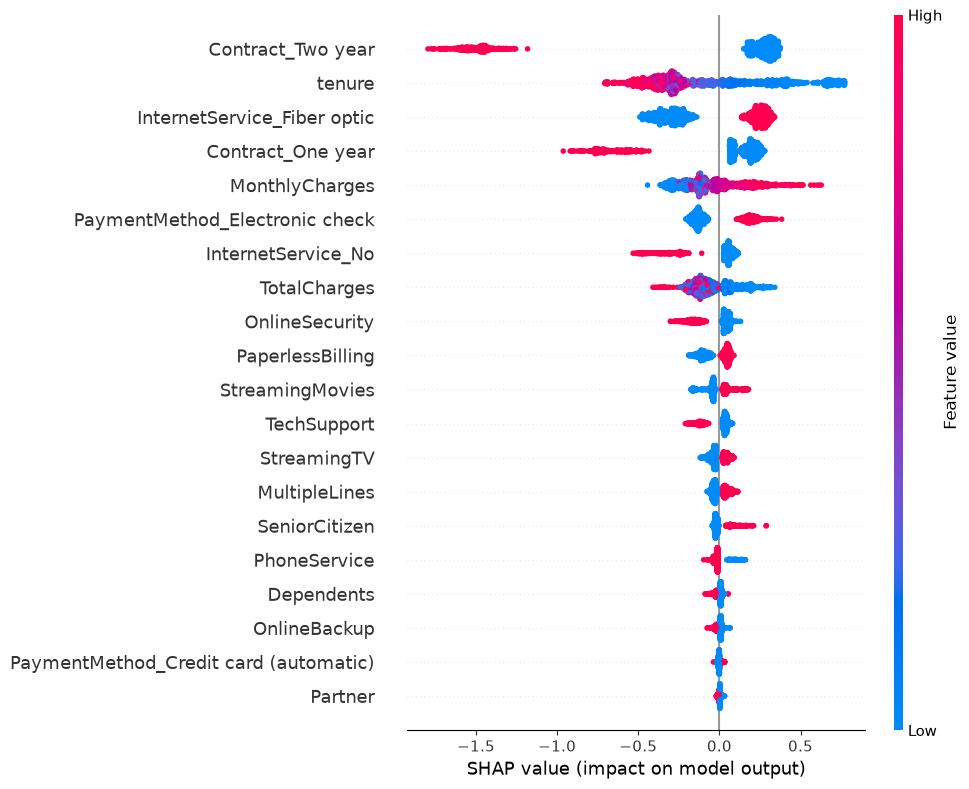

In [5]:
shap.summary_plot(shap_values.values, X_test, show=False)
fig = plt.gcf()
fig.set_size_inches(10, 8)
plt.tight_layout()
plt.show()

## 6. Per-Customer Explanations (Waterfall Plots)

A waterfall plot shows exactly how one customer's prediction was built, starting from the average prediction across all customers and adding or subtracting each feature's contribution until it reaches that customer's final predicted probability.

We will look at three cases side by side: a churner the model correctly flagged with high confidence, a churner the model missed, and a customer the model is confident will stay. Looking at all three together shows not just what the model gets right, but what it gets wrong and why.

One thing to keep in mind when reading the waterfall plots: the base value shown as E[f(X)] is close to 0, which corresponds to roughly a 50% baseline probability, not the actual 26.6% churn rate from the dataset. This is a side effect of scale_pos_weight reweighting the positive class during training, which shifts the model's effective baseline closer to 50/50 even though the real-world churn rate is much lower. It does not affect the validity of the explanations, it just means the starting point on each waterfall plot should not be read as the dataset's true churn rate.

In [6]:
# build a results table so customers can be selected by outcome and probability
test_results = pd.DataFrame({
    'actual': y_test.values,
    'predicted': xgb_preds,
    'probability': xgb_probs
}, index=y_test.index)

# case 1: a churner the model correctly flagged, picking the most confident one
churner_idx = test_results[
    (test_results['actual'] == 1) & (test_results['predicted'] == 1)
].sort_values('probability', ascending=False).index[0]

# case 2: a churner the model missed, picking the closest call rather than
# the most confidently wrong one, since a near miss is more instructive
missed_idx = test_results[
    (test_results['actual'] == 1) & (test_results['predicted'] == 0)
].sort_values('probability', ascending=False).index[0]

# case 3: a customer the model is most confident will stay
retained_idx = test_results[
    (test_results['actual'] == 0) & (test_results['predicted'] == 0)
].sort_values('probability', ascending=True).index[0]

print(f'Correctly flagged churner -- Customer ID: {churner_idx}, probability: {test_results.loc[churner_idx, "probability"]:.3f}')
print(f'Missed churner (near miss) -- Customer ID: {missed_idx}, probability: {test_results.loc[missed_idx, "probability"]:.3f}')
print(f'Confidently retained customer -- Customer ID: {retained_idx}, probability: {test_results.loc[retained_idx, "probability"]:.3f}')

Correctly flagged churner -- Customer ID: 5178-LMXOP, probability: 0.907
Missed churner (near miss) -- Customer ID: 4640-UHDOS, probability: 0.495
Confidently retained customer -- Customer ID: 6980-IMXXE, probability: 0.044


Case 1: Correctly Flagged Churner
Customer ID: 5178-LMXOP
Predicted churn probability: 0.907



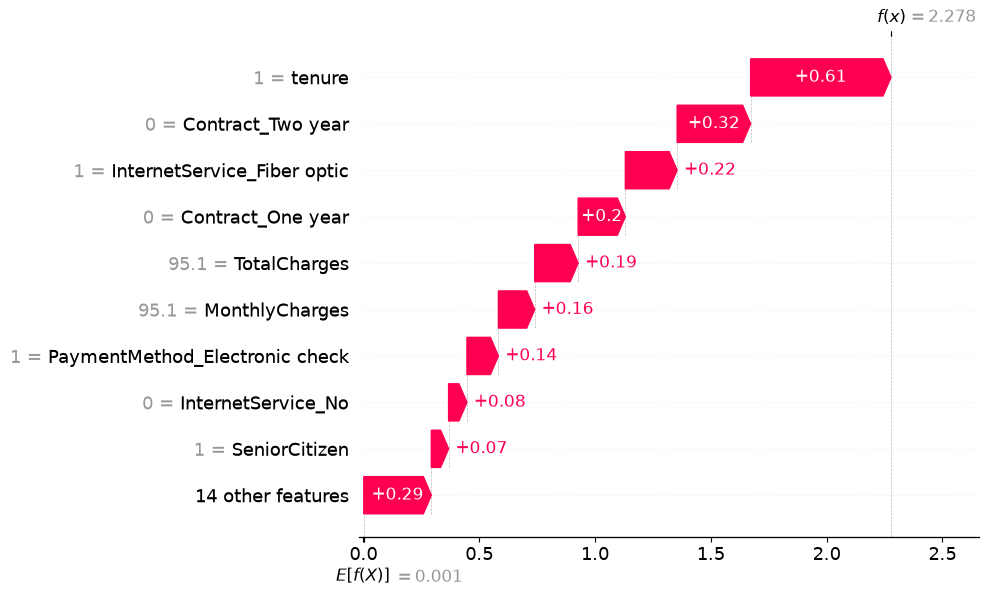

In [7]:
# case 1: correctly flagged churner
churner_pos = X_test.index.get_loc(churner_idx)

print('Case 1: Correctly Flagged Churner')
print(f'Customer ID: {churner_idx}')
print(f'Predicted churn probability: {test_results.loc[churner_idx, "probability"]:.3f}')
print()
shap.plots.waterfall(shap_values[churner_pos], max_display=10)

Case 2: Missed Churner (Near Miss)
Customer ID: 4640-UHDOS
Predicted churn probability: 0.495



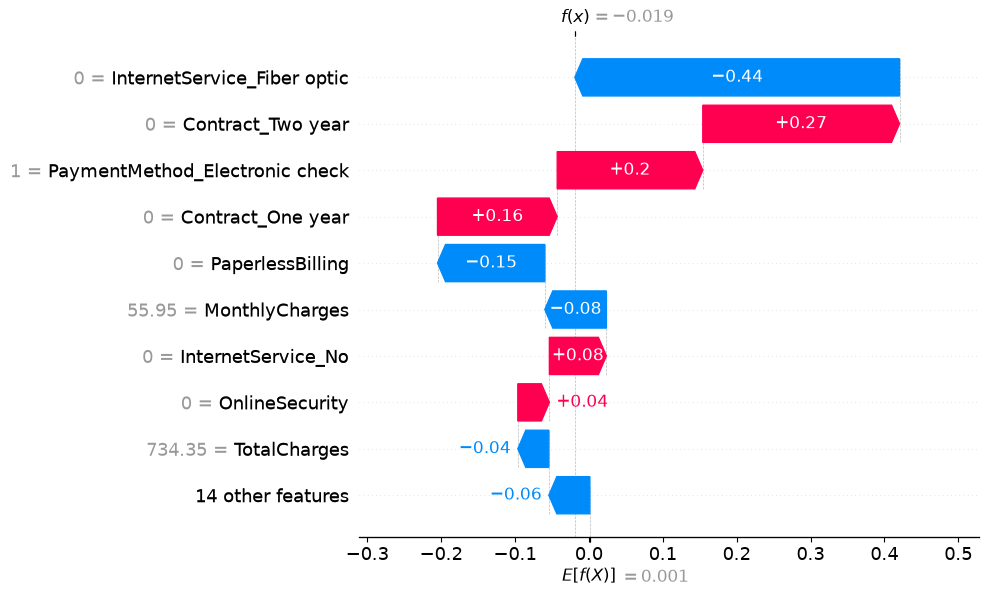

In [8]:
# case 2: missed churner (near miss)
missed_pos = X_test.index.get_loc(missed_idx)

print('Case 2: Missed Churner (Near Miss)')
print(f'Customer ID: {missed_idx}')
print(f'Predicted churn probability: {test_results.loc[missed_idx, "probability"]:.3f}')
print()
shap.plots.waterfall(shap_values[missed_pos], max_display=10)

Case 3: Confidently Retained Customer
Customer ID: 6980-IMXXE
Predicted churn probability: 0.044



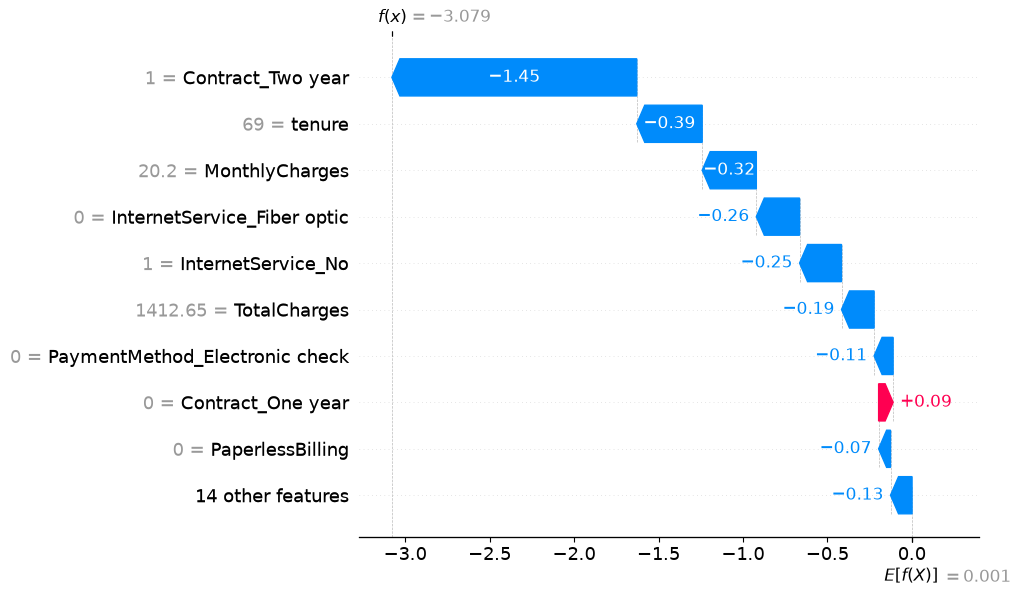

In [9]:
# case 3: confidently retained customer
retained_pos = X_test.index.get_loc(retained_idx)

print('Case 3: Confidently Retained Customer')
print(f'Customer ID: {retained_idx}')
print(f'Predicted churn probability: {test_results.loc[retained_idx, "probability"]:.3f}')
print()
shap.plots.waterfall(shap_values[retained_pos], max_display=10)

## 7. From SHAP Values to a Plain-Language Explanation

The waterfall plots are useful for a data scientist reading this notebook, but the Streamlit app needs something a retention team member can read at a glance without knowing what SHAP is. This section builds two functions that take the SHAP values for one customer and turn the top contributing features into something readable: one that produces a plain-language sentence, and one that produces a labeled bar chart for cases where a visual is more useful than text.

A lookup dictionary maps each feature to a human-readable phrase depending on whether its value is 1 or 0, since most of the encoded features are binary. Continuous features like tenure and monthly charges get their own formatting so the actual number shows up in the explanation rather than just the column name.

In [10]:
# phrase for value == 1, then phrase for value == 0
BINARY_LABELS = {
    'gender': ('being female', 'being male'),
    'SeniorCitizen': ('being a senior citizen', 'not being a senior citizen'),
    'Partner': ('having a partner', 'not having a partner'),
    'Dependents': ('having dependents', 'not having dependents'),
    'PhoneService': ('having phone service', 'not having phone service'),
    'MultipleLines': ('having multiple phone lines', 'not having multiple phone lines'),
    'OnlineSecurity': ('having online security', 'not having online security'),
    'OnlineBackup': ('having online backup', 'not having online backup'),
    'DeviceProtection': ('having device protection', 'not having device protection'),
    'TechSupport': ('having tech support', 'not having tech support'),
    'StreamingTV': ('having streaming TV', 'not having streaming TV'),
    'StreamingMovies': ('having streaming movies', 'not having streaming movies'),
    'PaperlessBilling': ('using paperless billing', 'not using paperless billing'),
    'InternetService_Fiber optic': ('having fiber optic internet', 'not having fiber optic internet'),
    'InternetService_No': ('having no internet service', 'having internet service'),
    'Contract_One year': ('being on a one year contract', 'not being on a one year contract'),
    'Contract_Two year': ('being on a two year contract', 'not being on a two year contract'),
    'PaymentMethod_Credit card (automatic)': ('paying by automatic credit card', 'not paying by automatic credit card'),
    'PaymentMethod_Electronic check': ('paying by electronic check', 'not paying by electronic check'),
    'PaymentMethod_Mailed check': ('paying by mailed check', 'not paying by mailed check'),
}

CONTINUOUS_LABELS = {
    'MonthlyCharges': 'a monthly charge of ${value:.2f}',
    'TotalCharges': 'a total spend of ${value:.2f}',
}

def describe_feature(feature, value):
    if feature in BINARY_LABELS:
        yes_label, no_label = BINARY_LABELS[feature]
        return yes_label if value == 1 else no_label
    elif feature == 'tenure':
        month_word = 'month' if round(value) == 1 else 'months'
        return f'a tenure of {value:.0f} {month_word}'
    elif feature in CONTINUOUS_LABELS:
        return CONTINUOUS_LABELS[feature].format(value=value)
    else:
        return f'{feature} = {value}'

def explain_prediction(shap_row_values, feature_values, feature_names, top_n=3):
    """Build a plain-language explanation from the top SHAP contributors for one customer."""
    contributions = list(zip(feature_names, shap_row_values, feature_values))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    top = contributions[:top_n]

    phrases = []
    for feature, shap_val, value in top:
        direction = 'increases' if shap_val > 0 else 'decreases'
        phrases.append(f'{describe_feature(feature, value)} ({direction} risk)')

    return 'The biggest factors in this prediction are ' + ', '.join(phrases) + '.'

def plot_explanation(shap_row_values, feature_values, feature_names, title=None, top_n=5):
    """Build a horizontal bar chart of the top SHAP contributors with plain-language labels."""
    contributions = list(zip(feature_names, shap_row_values, feature_values))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)
    top = contributions[:top_n]

    labels = [describe_feature(f, v) for f, _, v in top]
    values = [s for _, s, _ in top]
    colors = ['crimson' if v > 0 else 'steelblue' for v in values]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(labels[::-1], values[::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Impact on churn risk')
    if title:
        ax.set_title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    return fig

print('Plain-language explanation and chart functions ready.')

Plain-language explanation and chart functions ready.


In [11]:
# apply the explanation function to the same three customers from section 6
for label, pos, idx in [
    ('Correctly flagged churner', churner_pos, churner_idx),
    ('Missed churner (near miss)', missed_pos, missed_idx),
    ('Confidently retained customer', retained_pos, retained_idx)
]:
    explanation = explain_prediction(
        shap_values.values[pos],
        X_test.loc[idx].values,
        feature_cols
    )
    print(f'{label}:')
    print(f'  Customer ID: {idx}')
    print(f'  Churn probability: {test_results.loc[idx, "probability"]:.3f}')
    print(f'  {explanation}')
    print()

Correctly flagged churner:
  Customer ID: 5178-LMXOP
  Churn probability: 0.907
  The biggest factors in this prediction are a tenure of 1 month (increases risk), not being on a two year contract (increases risk), having fiber optic internet (increases risk).

Missed churner (near miss):
  Customer ID: 4640-UHDOS
  Churn probability: 0.495
  The biggest factors in this prediction are not having fiber optic internet (decreases risk), not being on a two year contract (increases risk), paying by electronic check (increases risk).

Confidently retained customer:
  Customer ID: 6980-IMXXE
  Churn probability: 0.044
  The biggest factors in this prediction are being on a two year contract (decreases risk), a tenure of 69 months (decreases risk), a monthly charge of $20.20 (decreases risk).



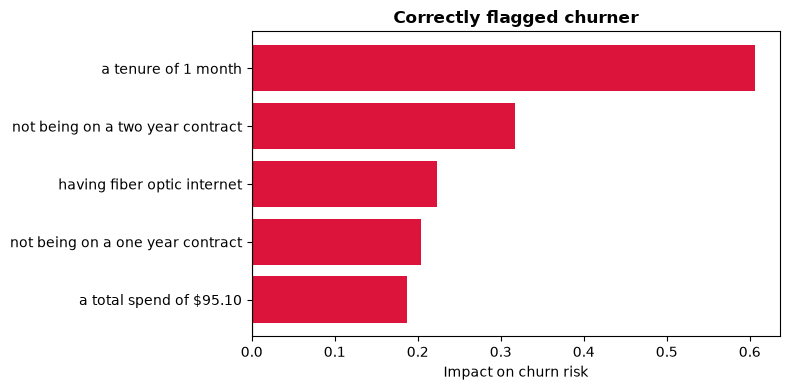

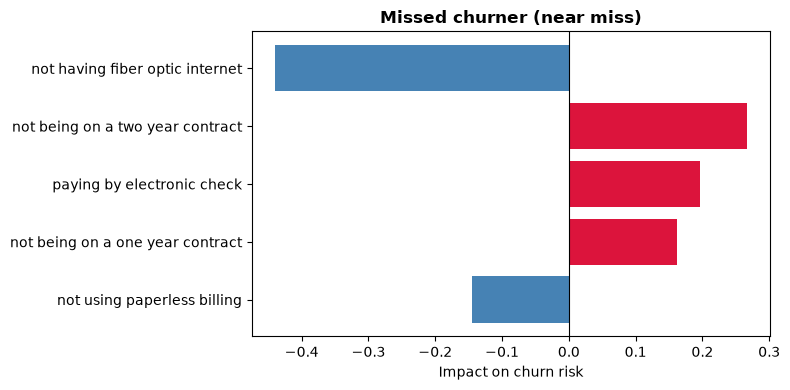

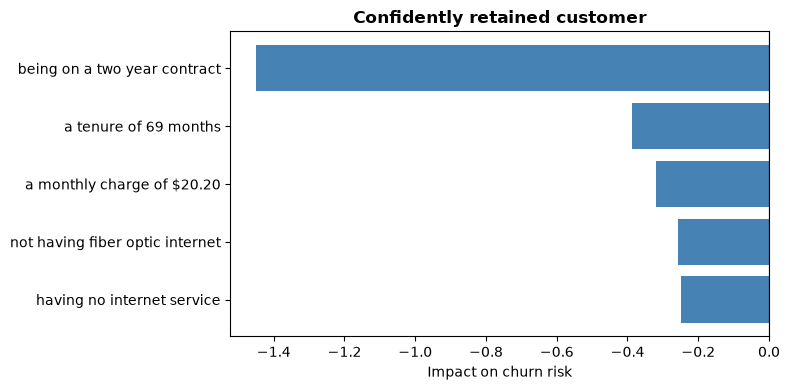

In [12]:
# validate the chart against the same three customers, comparing it
# to the sentences above and the original SHAP waterfall plots from section 6
for label, pos, idx in [
    ('Correctly flagged churner', churner_pos, churner_idx),
    ('Missed churner (near miss)', missed_pos, missed_idx),
    ('Confidently retained customer', retained_pos, retained_idx)
]:
    fig = plot_explanation(
        shap_values.values[pos],
        X_test.loc[idx].values,
        feature_cols,
        title=label
    )
    plt.show()

## 8. Confirm This Is Fast Enough for the App

The Streamlit app needs to generate a SHAP explanation the moment a user looks up a customer, not after a noticeable delay. Timing how long it takes to compute SHAP values for a single customer confirms whether this approach is actually usable in a real-time interface or whether it would need to be precomputed ahead of time instead.

In [13]:
single_customer = X_test.iloc[[0]]

start = time.time()
single_shap = explainer(single_customer)
elapsed = time.time() - start

print(f'Time to compute SHAP values for one customer: {elapsed*1000:.2f}ms')
print('This confirms SHAP explanations can be generated on the fly inside the Streamlit app')
print('without needing to precompute and store them in advance.')

Time to compute SHAP values for one customer: 2.62ms
This confirms SHAP explanations can be generated on the fly inside the Streamlit app
without needing to precompute and store them in advance.


## 9. Save

The explainer itself does not need to be saved since it is cheap to rebuild from the saved XGBoost model at runtime, which is exactly what `app.py` will do. What is worth saving is the global SHAP importance, since it is a useful reference for the final report and confirms the ranking matches what notebook 3's feature importance plot showed.

In [14]:
global_importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

global_importance.to_csv(MODELS_DIR + 'shap_global_importance.csv')

print(f'Saved global SHAP importance to: {MODELS_DIR}shap_global_importance.csv')
print()
print('Top 10 features by mean absolute SHAP value:')
print(global_importance.head(10))

Saved global SHAP importance to: ../models/shap_global_importance.csv

Top 10 features by mean absolute SHAP value:
Contract_Two year                0.5621
tenure                           0.3357
InternetService_Fiber optic      0.2827
Contract_One year                0.2706
MonthlyCharges                   0.1584
PaymentMethod_Electronic check   0.1546
InternetService_No               0.1213
TotalCharges                     0.1151
OnlineSecurity                   0.0796
PaperlessBilling                 0.0702
dtype: float32


## Summary

This notebook moved from a global view of feature importance to individual, plain-language explanations for specific customers.

### What the Summary Plot Confirmed

The SHAP summary plot largely agreed with the gain-based feature importance from notebook 3, with contract type and internet service type as the dominant features. The added value here is direction: the plot shows that having a two year contract consistently pushes predicted risk down, while fiber optic internet consistently pushes it up, which lines up with the correlation signs found in notebook 2.

Notice that tenure ranked 5th in notebook 3's gain-based feature importance at 0.034, but ranks 2nd here in SHAP importance at 0.336. Gain-based importance measures how often a feature gets used to split trees, while SHAP measures the actual average size of each feature's effect on individual predictions. Tenure apparently is not used for many splits, but when the model does use it, it swings predictions hard, which is visible in the waterfall plots where it contributes as much as 0.61 in a single prediction. This is a real disagreement between two legitimate importance measures, not an error in either one. 

### What the Three Customer Cases Showed

Looking at a correctly flagged churner, a missed churner, and a confidently retained customer side by side made the model's reasoning visible in a way the aggregate feature importance plot cannot. The near-miss case in particular is useful for understanding the model's blind spots, since it shows which factors pulled a real churner's predicted probability just under the decision threshold.

### Why This Approach Works for the App

SHAP computation for a single customer took well under a second, which means explanations can be generated live inside the Streamlit app rather than needing to be precomputed and stored for every customer in advance. Both `explain_prediction` and `plot_explanation`, built in section 7, are what the app will call directly to turn a customer's SHAP values into the sentence and chart shown alongside their risk score.

**Next step:** `app.py` -- build the Streamlit application that loads the saved model, accepts a customer lookup, and displays both the churn probability and the plain-language SHAP explanation.